# در این مثال دیتاست عیوب جوش مورد استفاده و یک مدل براساس آن آموزش داده می شود. 
دیتاست و مدل yolo8n.pt را دانلود و در پوشه کاری قرار دهید

### کتابخانه های مورد نیاز جهت نصب
!pip install pytorch opencv-python ultralytics

### ساختار دیتاست

در دیتاست تصاویر جوش های مختلف به همراه موقعیت عیوب و نوع آن مورد استفاده قرار می گیرد. ساختار دیتاست شامل عکس های هم نام با فایل متنی حاوی نوع عیب، مرکز و طول و عرض محدوده عیب است. به منظور آموزش مدل، دیتاست به 5 بخش حاوی داده های آموزشی و تست تبدیل می شود. سپس فرآیند آموزش مدل با شبکه عصبی انجام می گیرد
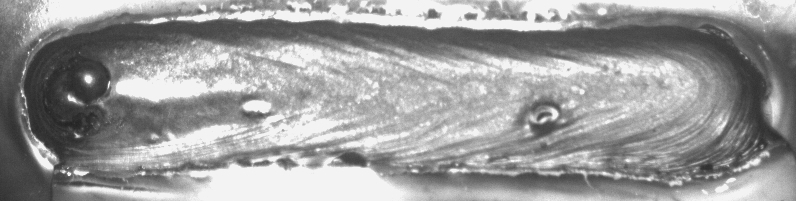  

یک کد پایتون برای تقسیم داده ها به 5 بخش مختلف با داده های آموزشی و تست طراحی شده و با دستور زیر اجرا می شود

!python create_kfold.py

هر بخش از داده آموزشی یا تست نیز حاوی دو پوشه زیرمجموعه تصویر و برچسب های آن است. 
ساختار کد به این صورت است که نام تصاویر در یک آرایه ذخیره شده 

array.append(image)

و 80 درصد آن به عنوان آموزش و 20 درصد به عنوان تست تقسیم می شوند 

X_train, X_test = train_test_split(iarray, test_size=0.2, random_state=1)

سپس اسکریپی برای کپی تصاویر و برچسب ها ساخته می شود

cp source/image.jpg destination/test/images
cp source/image.yolo destination/test/labels/image.txt

در نهایت برای اغتبارسنجی متقابل 5 بخش ایجاد می شود.

kfold = KFold(n_splits=5, shuffle=True, random_state=100)

ساختار خروجی به صورت زیر خواهد بود

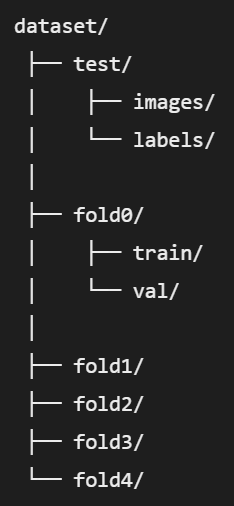

### نوع عیوب

4 نوع عیب به صورت زیر در دیتاست برچسب گذاری شده است

mdict = {
  "pore": 0,
  "deposit": 1,
  "discontinuity": 2,
  "stain": 3
}

### فراخوانی کتابخانه های مورد نیاز

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch
import os
import yaml
from pathlib import Path

WARNING Known issue with torch==2.4.0 on Windows with CPU, recommend upgrading to torch>=2.4.1 to resolve https://github.com/ultralytics/ultralytics/issues/15049


### توابع بارگذاری تصویر و فایل برچسب ها

In [2]:
# فراخوانی تصاویر
def load_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# فراخوانی برچسب ها
def load_yolo_label(label_path):
    boxes = []
    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, xc, yc, w, h = map(float, line.strip().split())
            boxes.append([int(cls), xc, yc, w, h])
    return boxes

# تبدیل برچسب ها به مختصات پیکسلی
def yolo_to_pixel(box, img_w, img_h):
    cls, xc, yc, w, h = box

    xc *= img_w
    yc *= img_h
    w  *= img_w
    h  *= img_h

    x1 = int(xc - w/2)
    y1 = int(yc - h/2)
    x2 = int(xc + w/2)
    y2 = int(yc + h/2)

    return cls, x1, y1, x2, y2

# رسم مستطیل روی تصویر (برای برای بررسی برچسب ها)
def show_boxes(img, boxes):
    img_h, img_w = img.shape[:2]
    img_copy = img.copy()

    for b in boxes:
        cls, x1, y1, x2, y2 = yolo_to_pixel(b, img_w, img_h)
        cv2.rectangle(img_copy, (x1,y1), (x2,y2), (255,0,0), 2)
        cv2.putText(img_copy, str(cls), (x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

    plt.imshow(img_copy)
    plt.axis('off')
    plt.show()


In [3]:
# پیش پردازش شامل نرمال سازی و کاهش نویز در صورت نیاز
def preprocess_image(img, size=640):
    img = cv2.resize(img, (size, size))

    # Normalize
    img = img.astype(np.float32) / 255.0

    # Optional: denoise
    img = cv2.GaussianBlur(img, (3,3), 0)

    return img

### تشدید با استفاده از کتابخانه albumentations 
##### در صورت نیاز استفاده شود
!pip install albumentations
import albumentations as A

augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.MotionBlur(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05,
                       scale_limit=0.1,
                       rotate_limit=10,
                       p=0.4)
], bbox_params=A.BboxParams(format='yolo'))

def augment_sample(img, boxes):
    augmented = augment(image=img, bboxes=[b[1:] for b in boxes], class_labels=[b[0] for b in boxes])
    img_aug = augmented["image"]
    
    # ترکیب مجدد کلاس + bbox
    new_boxes = []
    for cls, (xc,yc,w,h) in zip([b[0] for b in boxes], augmented["bboxes"]):
        new_boxes.append([cls, xc, yc, w, h])
    
    return img_aug, new_boxes



### بررسی یکی از تصاویر

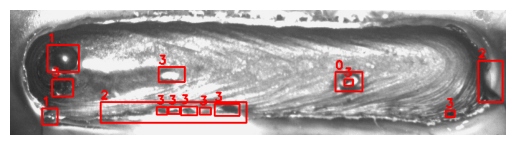

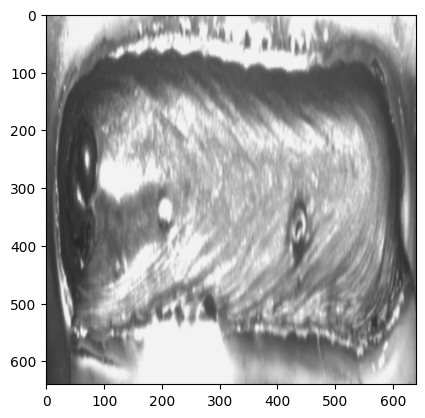

In [4]:
img_path = "weld-dataset/high_resolution_welds/25_2.jpg"
label_path = "weld-dataset/high_resolution_welds/25_2.yolo"

img = load_image(img_path)
boxes = load_yolo_label(label_path)

show_boxes(img, boxes)

img_prep = preprocess_image(img)
plt.imshow(img_prep)
#img_aug, new_boxes = augment_sample(img_prep, boxes)
#show_boxes((img_aug*255).astype(np.uint8), new_boxes)

برای تشخیص و مکان‌یابی عیوب در تصاویر جوشکاری از مدل
YOLOv8
استفاده می‌شود. انتخاب این مدل به دلیل توانایی بالای آن در تشخیص اشیاء در زمان واقعی و دقت مناسب در شناسایی نواحی کوچک و نامنظم است که در مسئله تشخیص عیوب جوش اهمیت زیادی دارد

### ساخت فایل fold_data.yaml
این فایل جهت آموزش مدل باید برای هر بخش ساخته شود.

In [5]:
# ==================== تنظیمات اولیه ====================
BASE_PATH = Path("weld-dataset/kfold_high")          # مسیر اصلی دیتاست
FOLDS = [f"fold{i}" for i in range(5)]  # نام بخش ها
TEST_PATH = BASE_PATH / "test"          # مسیر مجموعه تست
CLASS_NAMES ={
  0: 'pore',
  1: 'deposit',
  2: 'discontinuity',
  3: 'stain'}

for fold in FOLDS:
    print(f"\n======= شروع ساخت فایل پیش نیاز برای بخش {fold} =======")
    
    # مسیرهای train و val برای این فولد
    train_path = BASE_PATH / fold / "train"
    val_path = BASE_PATH / fold / "val"
    
    # ساخت فایل data.yaml موقت
    data_config = {
        "path": str(BASE_PATH.resolve()),
        "train": str(train_path.resolve()),
        "val": str(val_path.resolve()),
        "nc": len(CLASS_NAMES),
        "names": CLASS_NAMES
    }
    yaml_file = BASE_PATH / f"{fold}_data.yaml"
    with open(yaml_file, "w") as f:
        yaml.dump(data_config, f, default_flow_style=False)


======= شروع ساخت فایل پیش نیاز برای بخش fold0 =======

======= شروع ساخت فایل پیش نیاز برای بخش fold1 =======

======= شروع ساخت فایل پیش نیاز برای بخش fold2 =======

======= شروع ساخت فایل پیش نیاز برای بخش fold3 =======

======= شروع ساخت فایل پیش نیاز برای بخش fold4 =======


### فرآیند یادگیری با استفاده از مدل Yolo
به این منظور فایل زیر را در پوشه کاری قرار دهید.
    yolov8n.pt

In [10]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = "runs_fold_cv"   # دایرکتوری ذخیره نتایج

for fold in FOLDS:
    yaml_file = BASE_PATH / f"{fold}_data.yaml"
    # بارگیری مدل پایه
    model = YOLO('yolov8n.pt')
    print(f"\n======= شروع یادگیری برای بخش {fold} =======")
    model.train(
        data=str(yaml_file),
        epochs=50,
        imgsz=640,
        batch=4,
        device=DEVICE,
        project=PROJECT_DIR,
        name=fold,                 # هر بخش در زیرپوشه جداگانه ذخیره می‌شود
        exist_ok=True,
        verbose=True
    )



======= شروع یادگیری برای بخش fold0 =======
Ultralytics 8.4.37  Python-3.9.23 torch-2.4.0+cpu CPU (Intel Core i5-10210U 1.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=weld-dataset\kfold_high\fold0_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fold0, nbs=64, nms=False, opset=None, optimize=F

### فایل های ذخیره شده در سیستم پس از آموزش

\runs\detect\runs_fold_cv\fold*
پس از آموزش، پوشه ای برای هر بخش ایجاد می شود که حاوی بهترین مدل، آخرین مدل و نتایج مختلف نیز شامل نمودار های زیر ایجاد می شود.
F1-Confidence plot (F1=2*(Precision*Recall)/(Precision+Recall)) نمودار آستانه اطمینان به مقدار امتیاز 
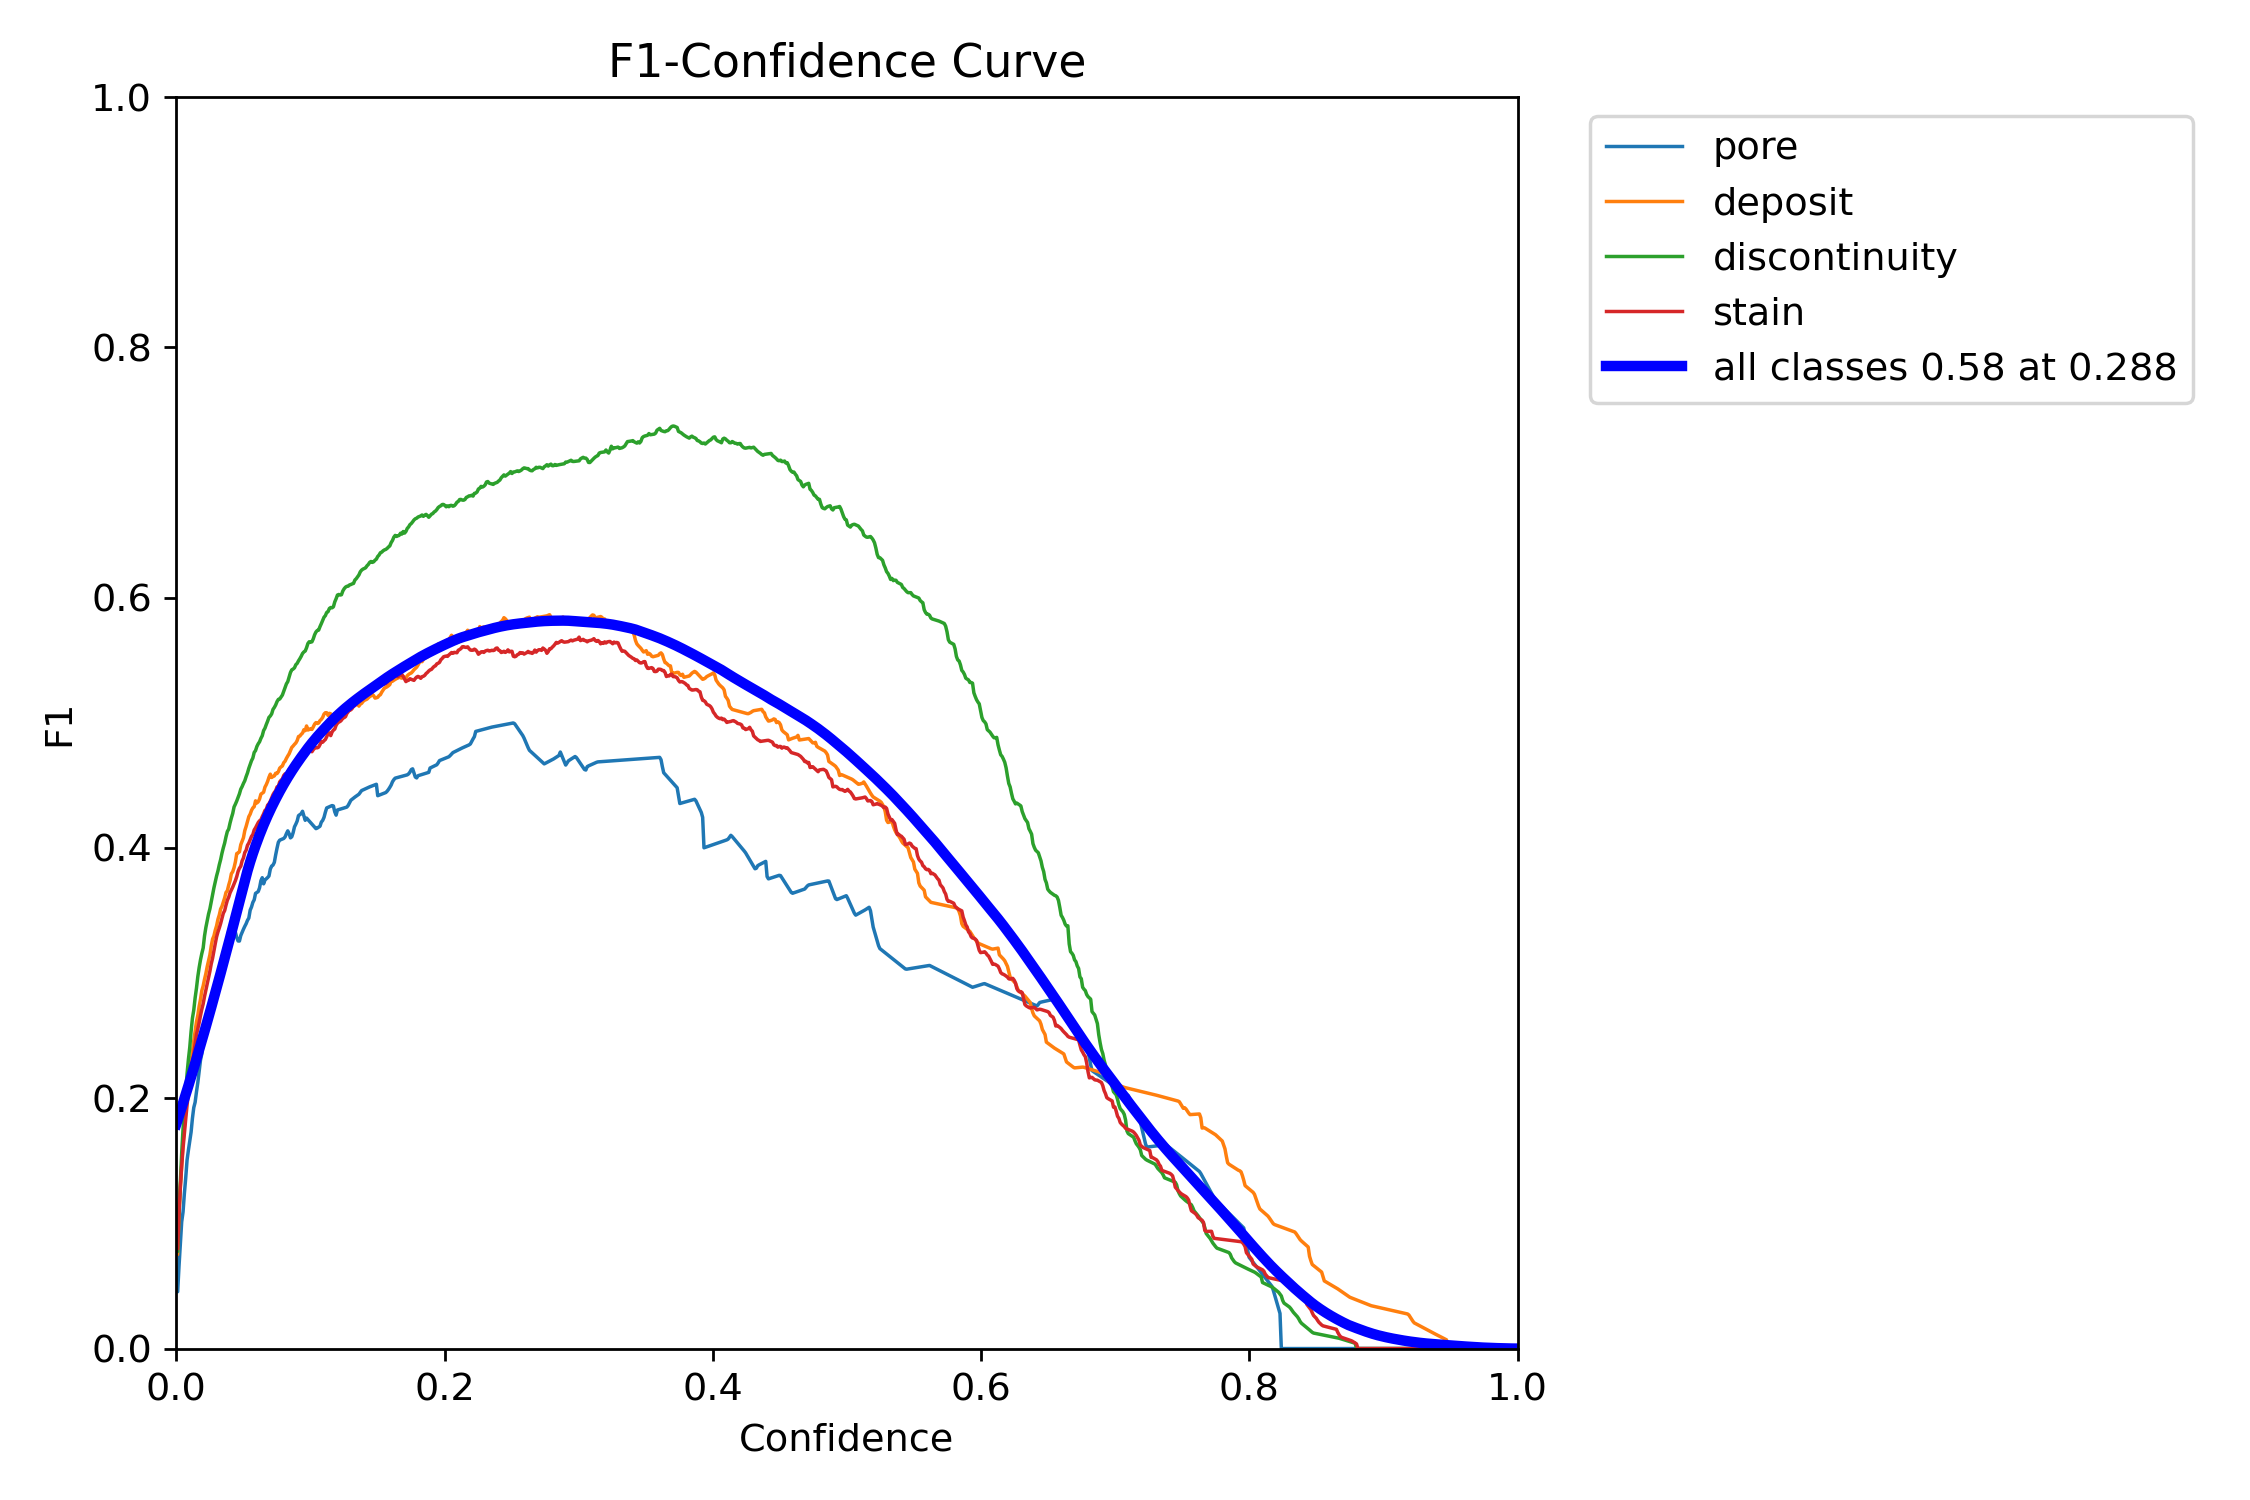
Precision-Confidence plot (Precition=TP/(TP+FP)) نمودار دقت به سطح اطمینان انتخابی
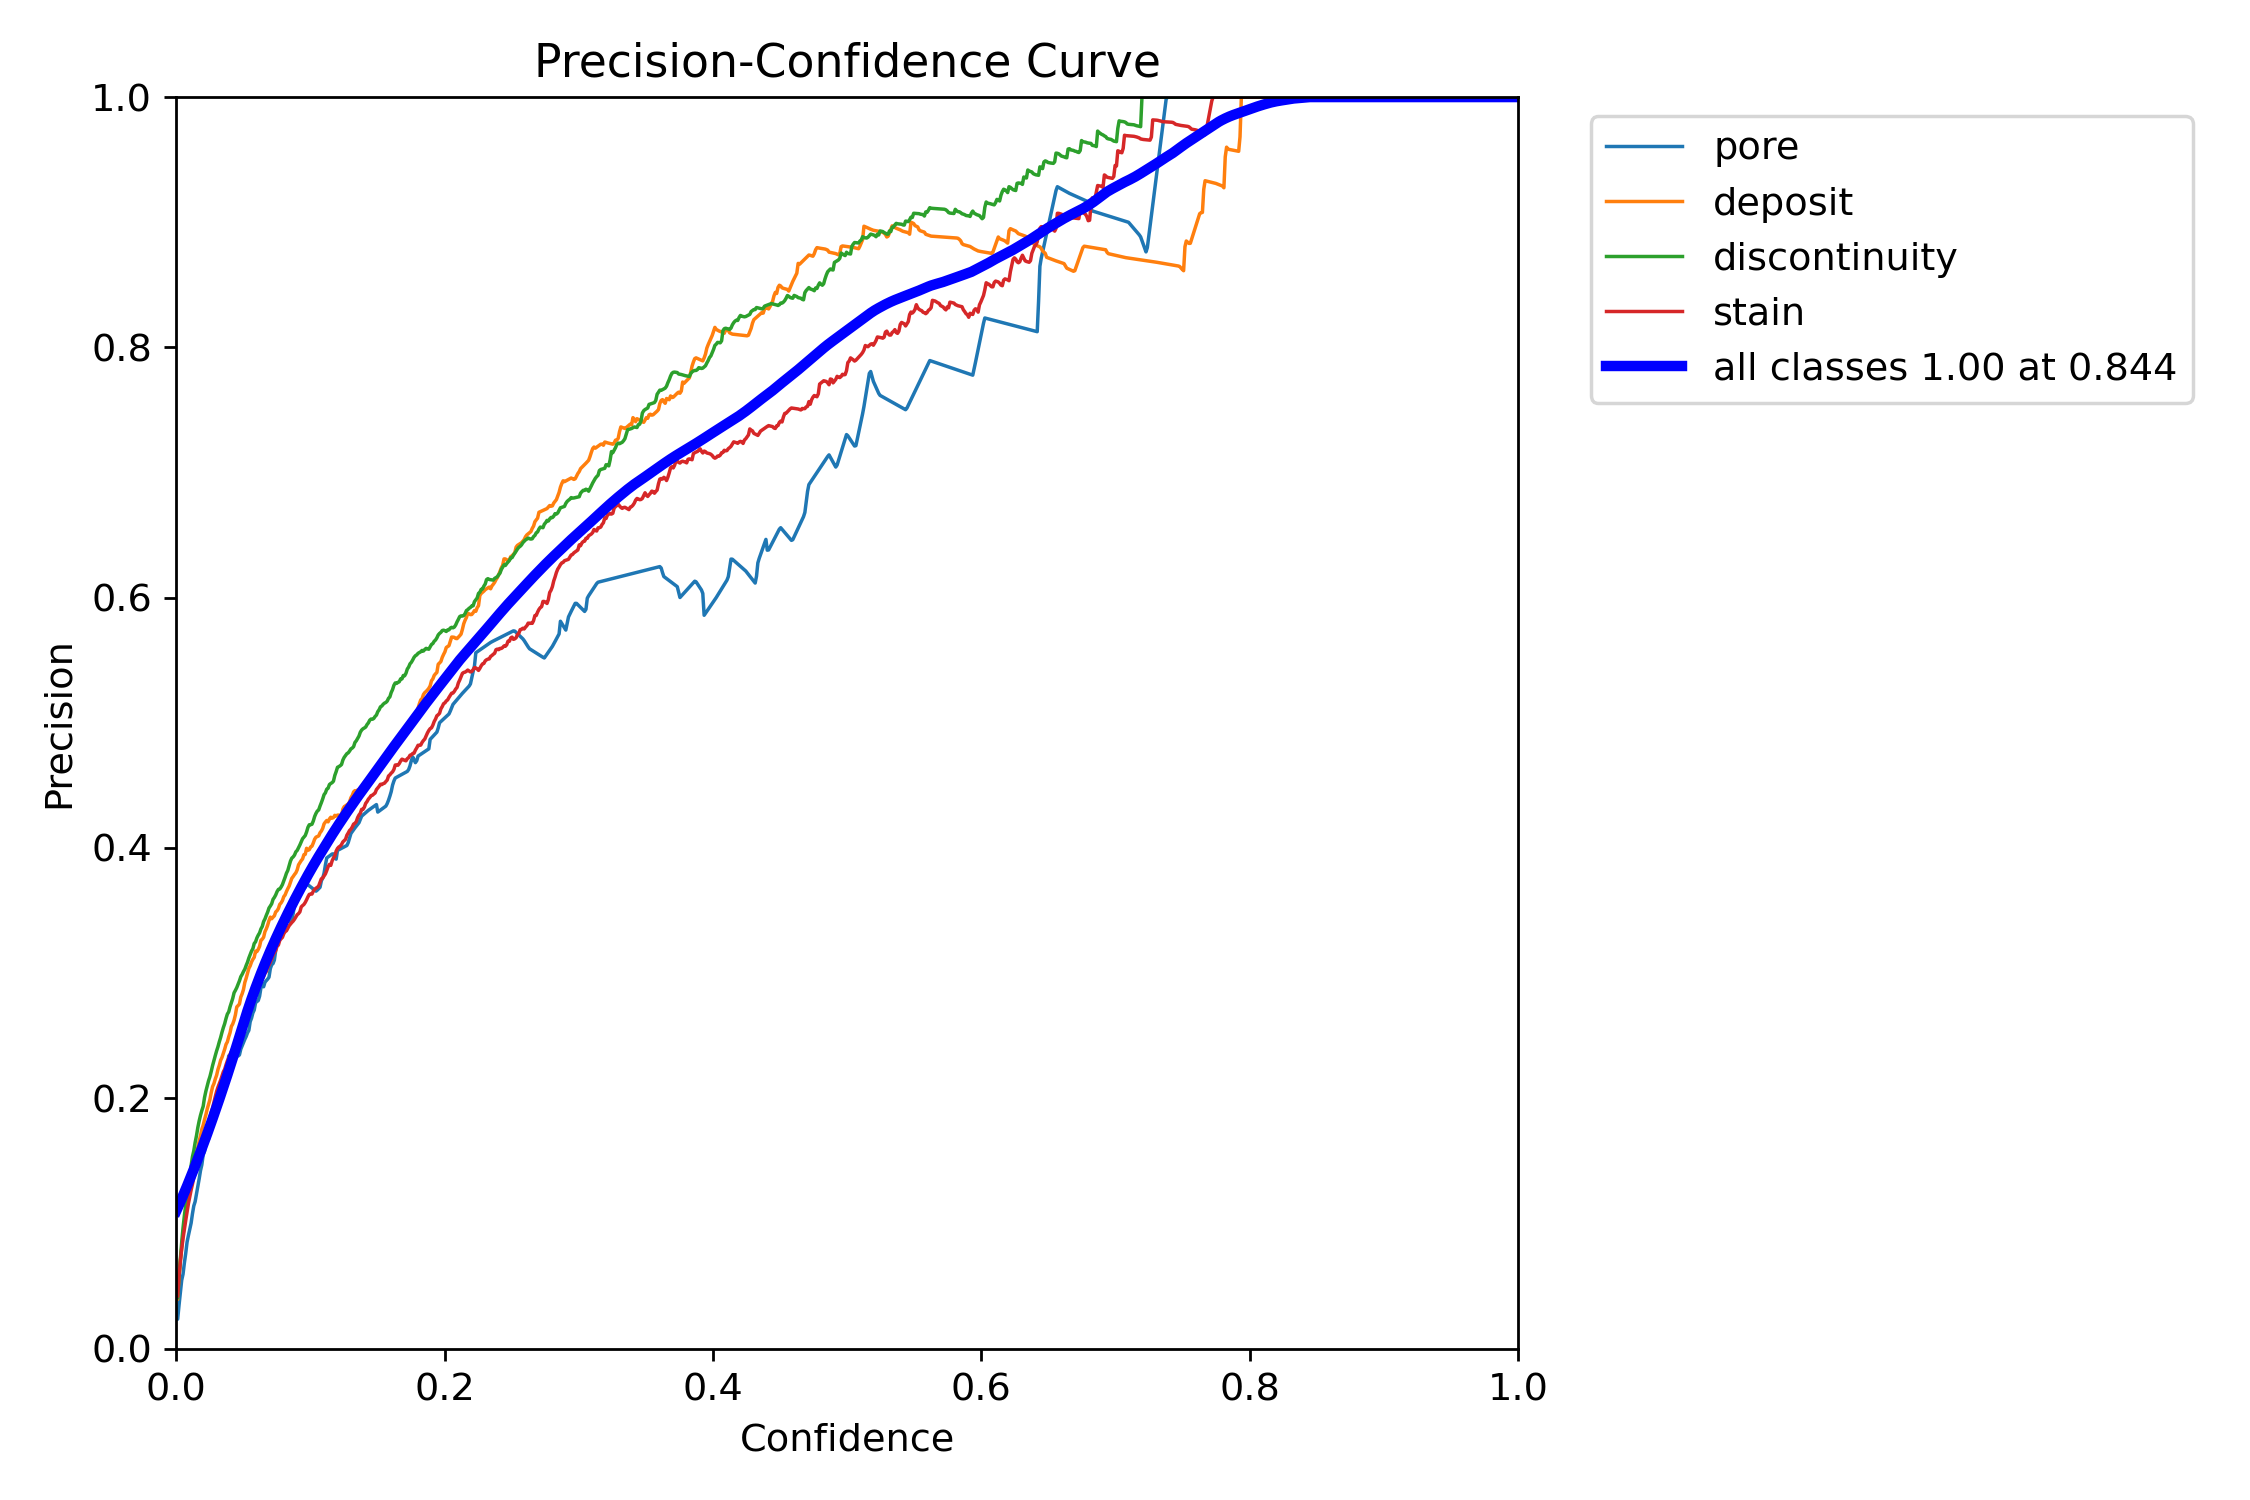
Precision-Recall plot (Recall = TP/(TP/FN)) نمودار دقت به Recall
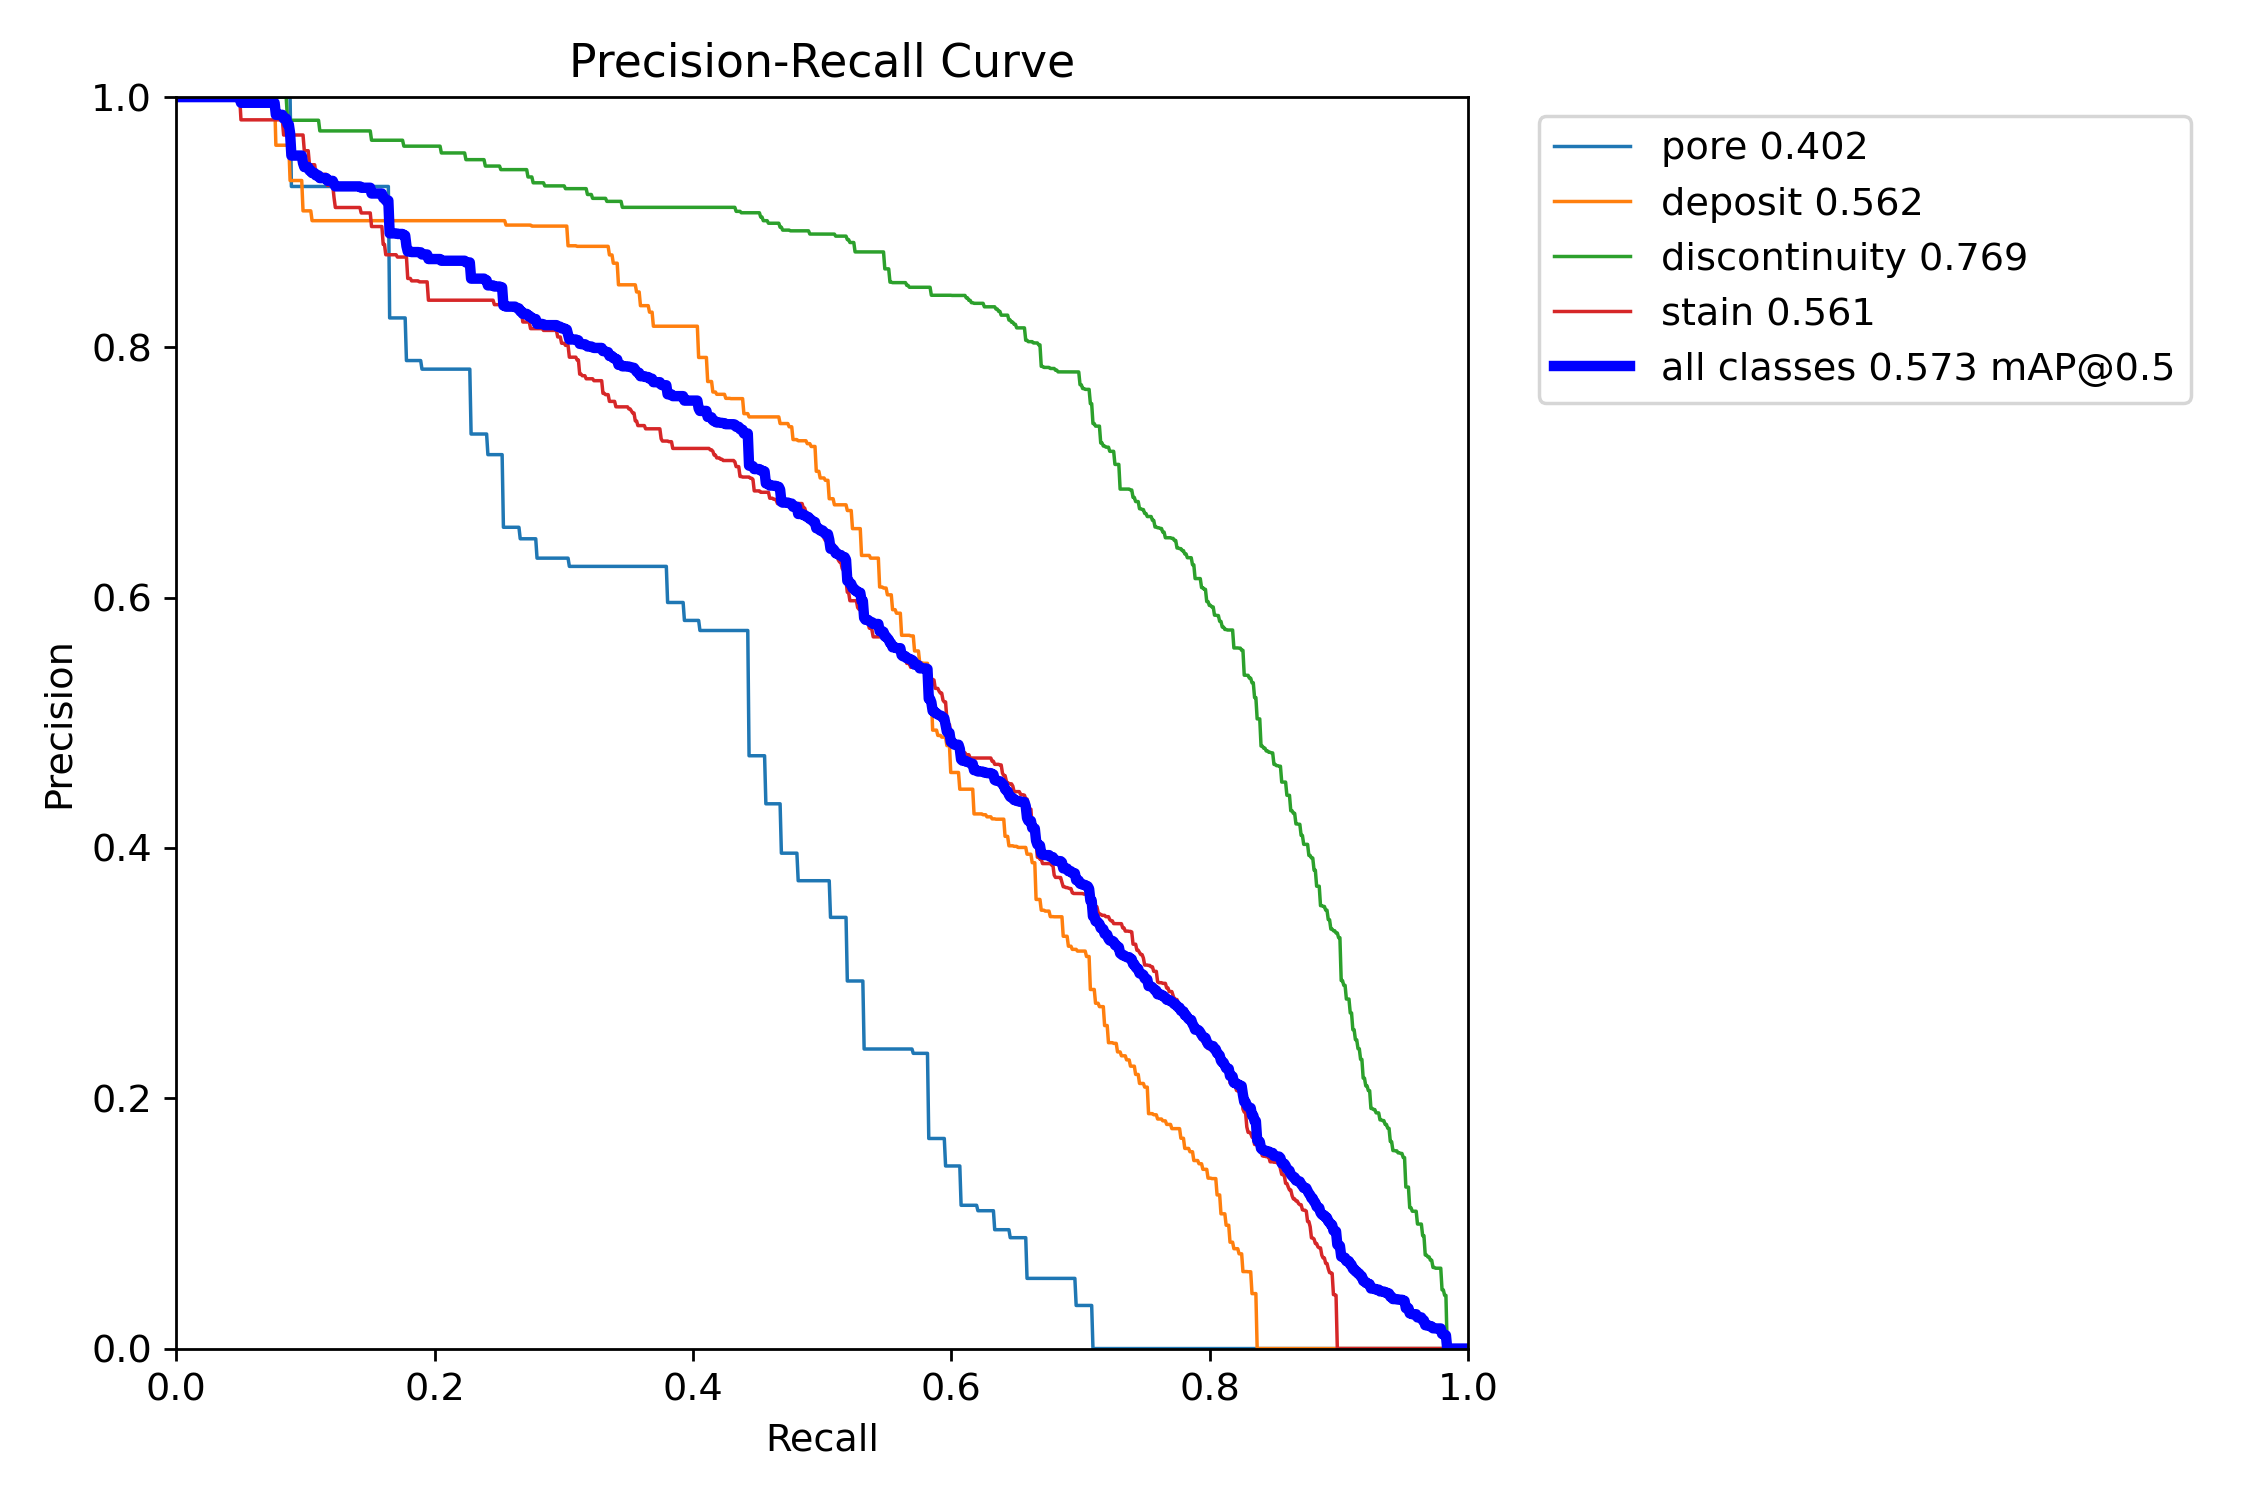
Recall-Confidence plot 
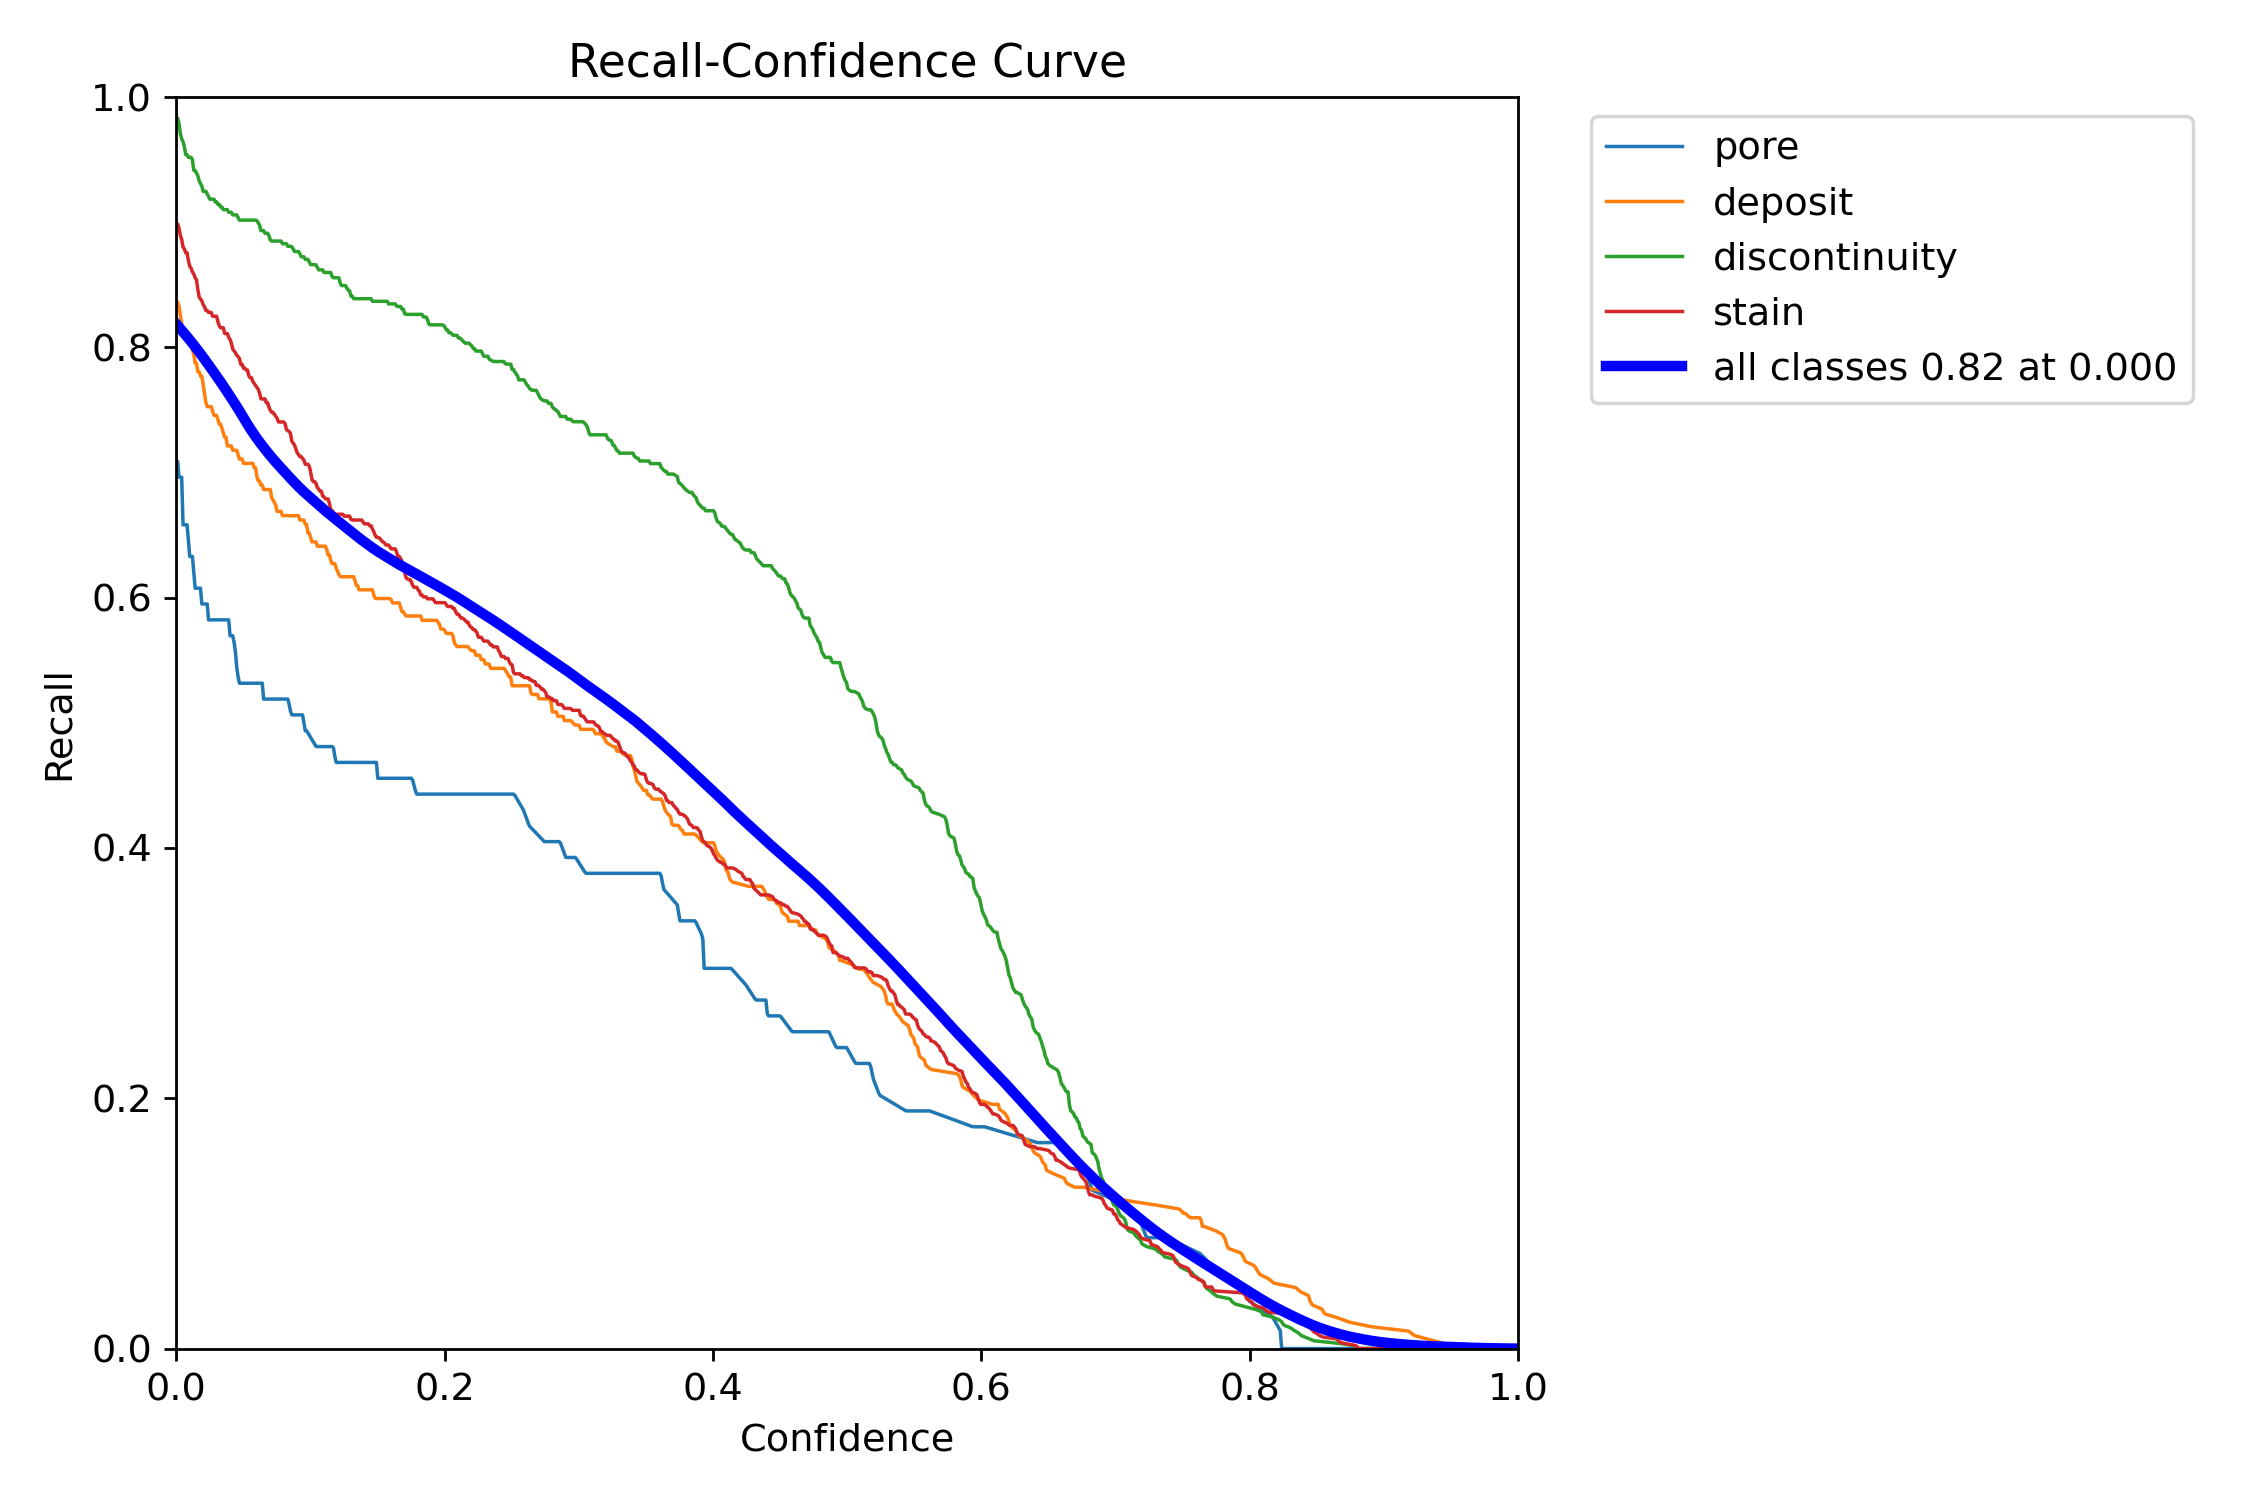
Confusion Matrix ماتریس درهم تنیدگی
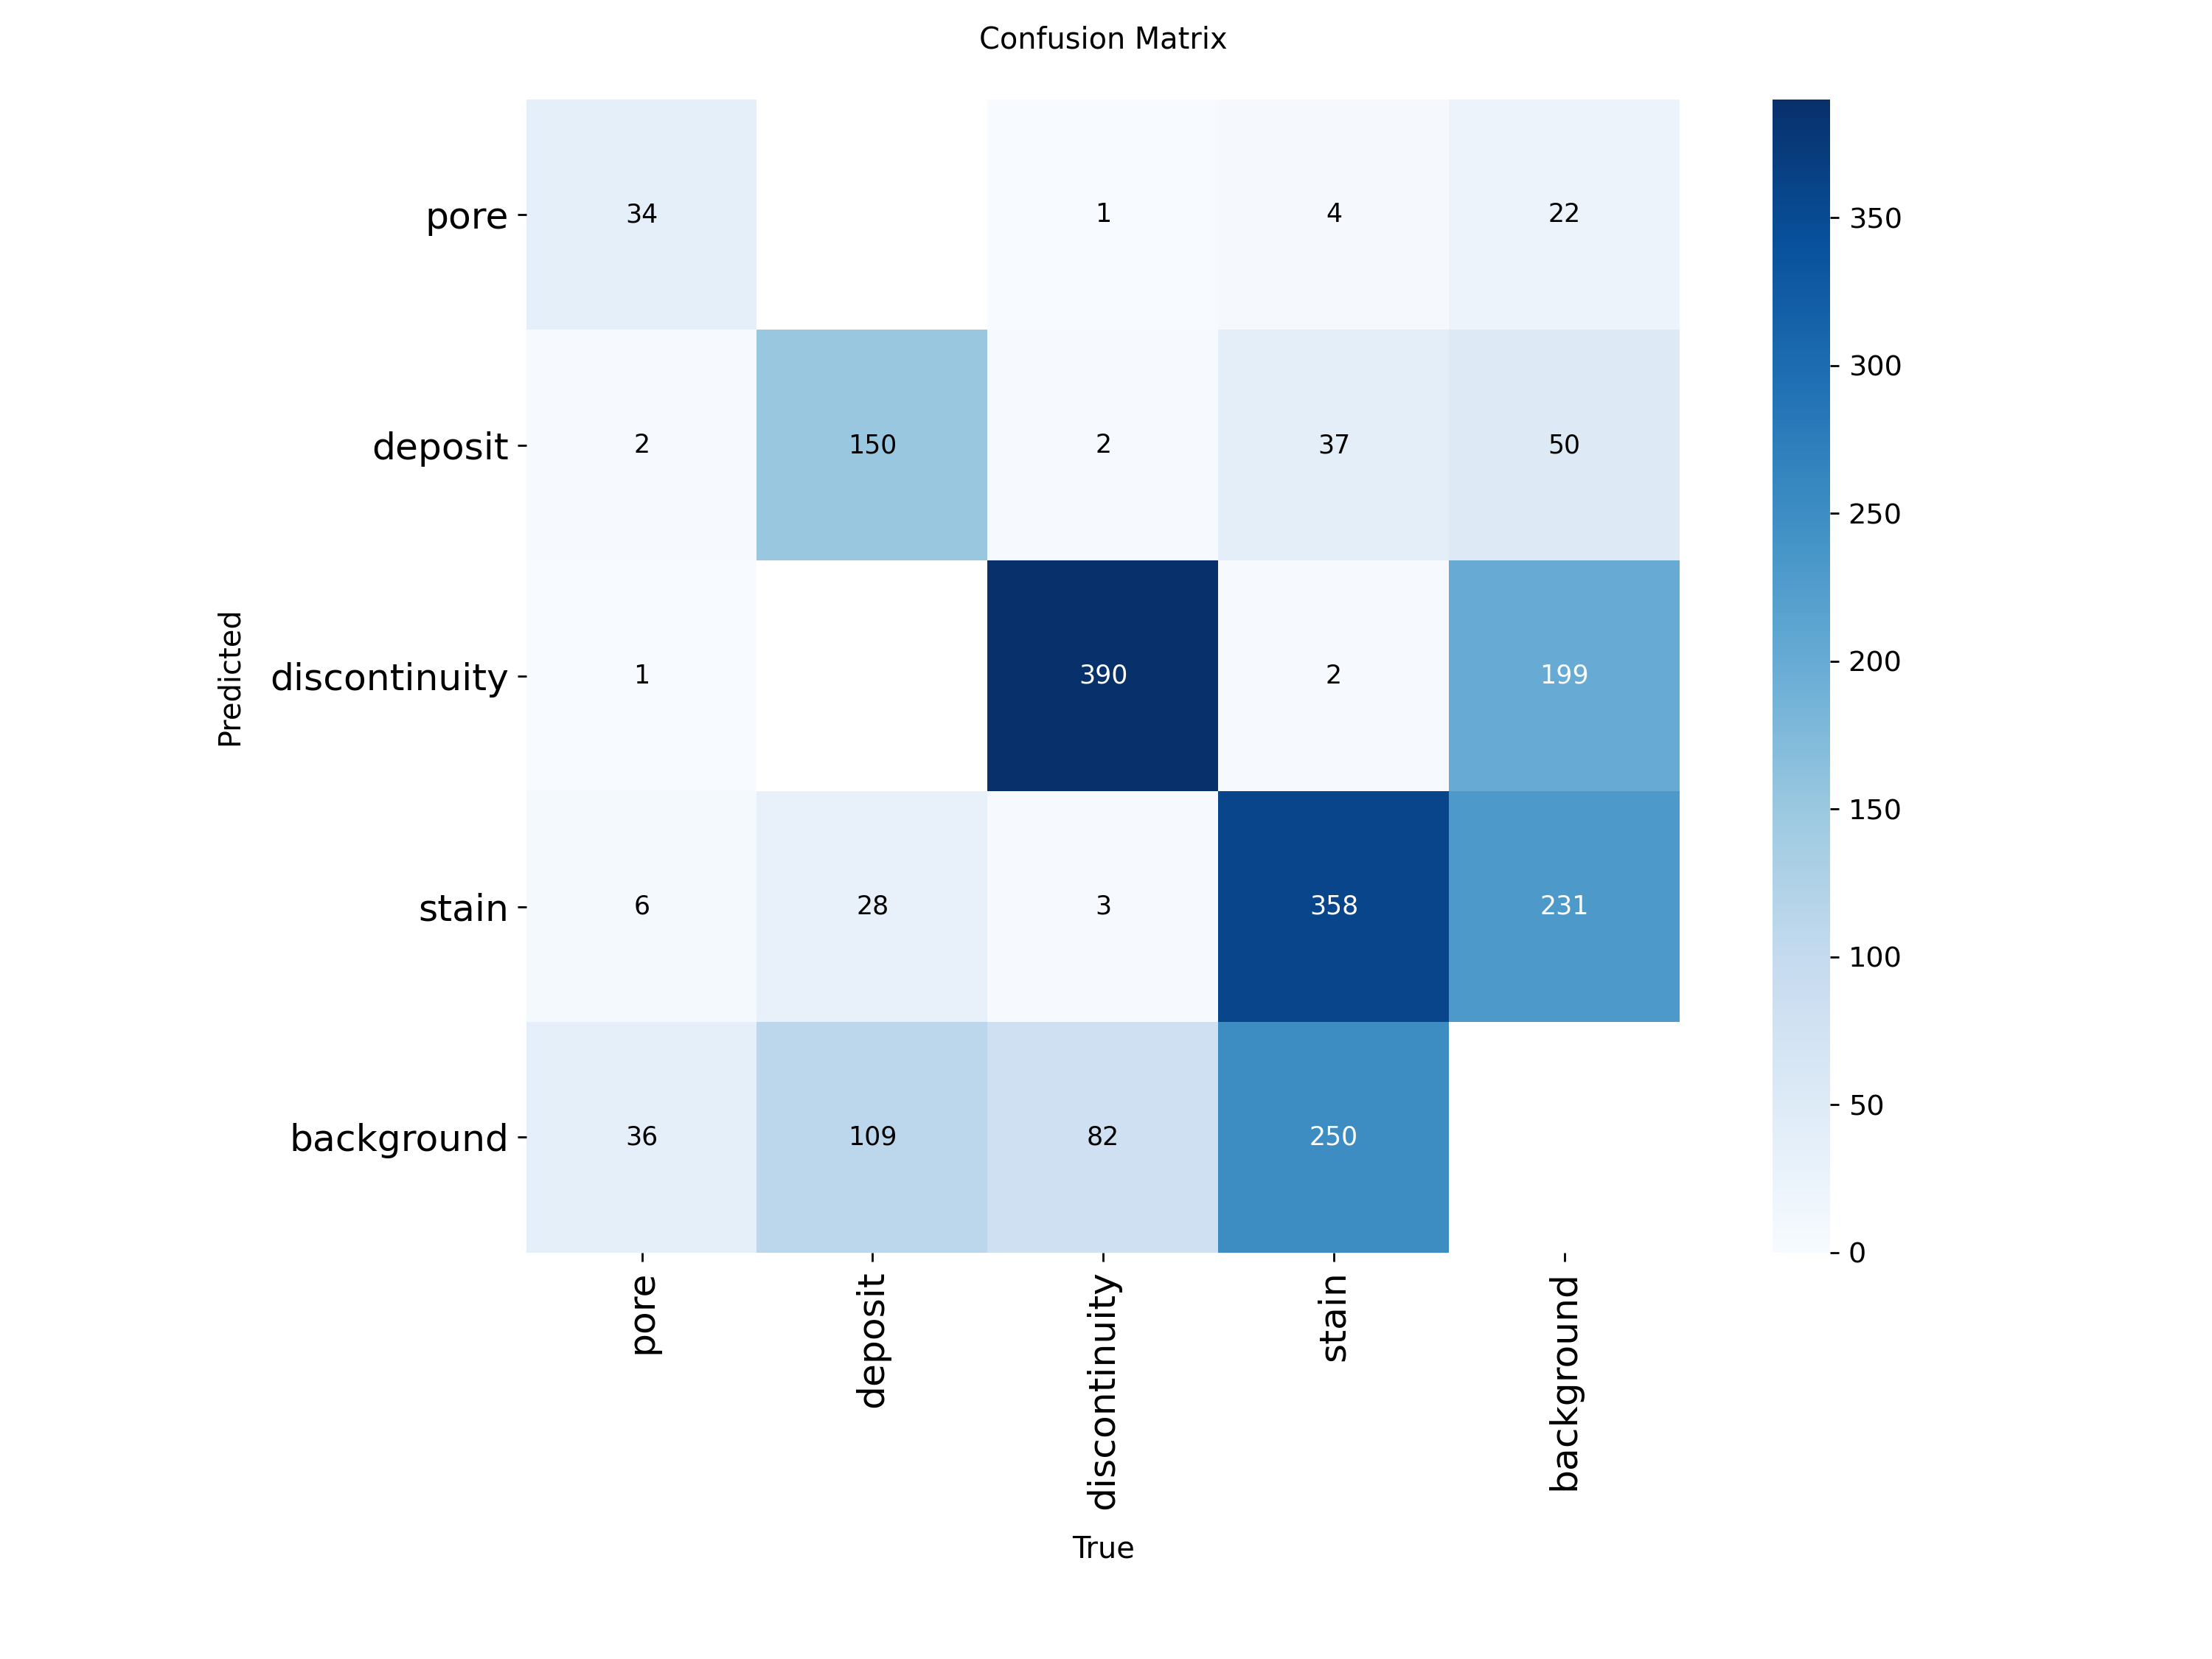

### ارزیابی مدل

یک فایل با عنوان data_test.yaml در مسیر اشاره شده با مشخصات زیر بسازید

path: C:\Users\****\Documents\GitHub\AI-in-Oil-and-gas-industry\ex4-8  #موقعیت پوشه کاری

test: weld-dataset\kfold_high\test\images
train: weld-dataset\kfold_high\test\images
val: weld-dataset\kfold_high\test\images

names:
  0: pore
  1: deposit
  2: discontinuity
  3: stain

In [20]:
import pandas as pd

folds = ["fold0","fold1","fold2","fold3","fold4"]

results = []

for f in folds:

    model_path = f"runs/detect/runs_fold_cv/{f}/weights/best.pt"
    model = YOLO(model_path)

    metrics = model.val(
        data="weld-dataset\kfold_high\data_test.yaml",
        split="test",
        device="cpu",
        imgsz=416
    )

    mAP50 = metrics.box.map50
    mAP5095 = metrics.box.map

    results.append({
        "fold": f,
        "mAP50": mAP50,
        "mAP50-95": mAP5095
    })

df = pd.DataFrame(results)
print(df)

Ultralytics 8.4.37  Python-3.9.23 torch-2.4.0+cpu CPU (Intel Core i5-10210U 1.60GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 554.6127.6 MB/s, size: 104.1 KB)
val: Scanning C:\Users\lian tech\Documents\GitHub\AI-in-Oil-and-gas-industry\ex4-8\weld-dataset\kfold_high\test\labels.cache... 205 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 205/205  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.2it/s 4.1s0.3s
                   all        205       1928      0.611      0.514      0.511      0.223
                  pore         45         86      0.726      0.349      0.382      0.149
               deposit        165        390      0.522      0.456      0.433      0.221
         discontinuity        205        596      0.648      0.798       0.77       0.32
                 stain        194        856      0.548      0.454   

### انتخاب بهترین مدل و میانگین اعتبارسنجی متقابل

In [23]:
best = df.loc[df["mAP50-95"].idxmax()]
print("بهترین مدل:", best)

print('میانگین:', df[["mAP50","mAP50-95"]].mean())

بهترین مدل: fold           fold3
mAP50       0.543539
mAP50-95    0.234471
Name: 3, dtype: object
میانگین: mAP50       0.528826
mAP50-95    0.227093
dtype: float64



image 1/1 C:\Users\lian tech\Documents\GitHub\AI-in-Oil-and-gas-industry\ex4-8\test.jpg: 160x640 1 deposit, 4 discontinuitys, 8 stains, 47.2ms
Speed: 1.5ms preprocess, 47.2ms inference, 1.1ms postprocess per image at shape (1, 3, 160, 640)


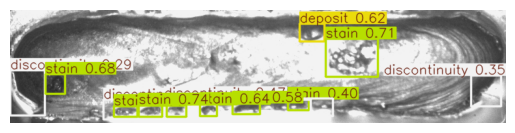

In [30]:
model = YOLO("runs/detect/runs_fold_cv/fold3/weights/best.pt")

results = model.predict(source="test.jpg")

img = results[0].plot()
plt.imshow(img)
plt.axis('off')
plt.show()

## ساخت مدل برای تصاویر دلخواه با روش بالا قابل انجام است ولی نیاز به دیتاست دارد.
### نحوه برچسب گذاری دیتاست

در پایان اگر تصاویر اختصاصی خود را دارید می توانید از labelImg برای برچسب گذاری استفاده کنید

pip install labelImg

سپس اجرای labelImg و مشخص کردن پوشه تصاویر، پوشه خروجی برچسب ها و فرمت خروجی برچسب ها و ترسیم مستطیل ها .

# تقسیم داده ها به دو بخش آموزشی و اعتبارسنجی
import os, shutil, random

dataset_dir = "my_dataset"
images_dir = os.path.join(dataset_dir, "images")
labels_dir = os.path.join(dataset_dir, "labels")
train_ratio = 0.8  # 80% داده به بخش آموزش می‌رود

# دریافت نام فایل‌ها (بدون پسوند)
image_files = [f.split('.')[0] for f in os.listdir(images_dir)]
random.shuffle(image_files)  # تصادفی کردن داده‌ها برای جلوگیری از سوگیری

# محاسبه نقطه تقسیم
split_idx = int(len(image_files) * train_ratio)
train_files = image_files[:split_idx]
val_files = image_files[split_idx:]

# ساختار پوشه‌های جدید
for split, files in [('train', train_files), ('val', val_files)]:
    os.makedirs(f"{dataset_dir}/{split}/images", exist_ok=True)
    os.makedirs(f"{dataset_dir}/{split}/labels", exist_ok=True)
    for f in files:
        shutil.move(f"{images_dir}/{f}.jpg", f"{dataset_dir}/{split}/images/{f}.jpg")
        shutil.move(f"{labels_dir}/{f}.txt", f"{dataset_dir}/{split}/labels/{f}.txt")

# پاک کردن پوشه‌های قدیمی (اختیاری)
shutil.rmtree(images_dir)
shutil.rmtree(labels_dir)
print("داده‌ها با موفقیت تقسیم شدند!")

# ایجاد فایل data.yaml
names:
  - 'نام کلاس اول'   # مانند 'hat' یا 'plate'
  - 'نام کلاس دوم'   # اگر بیش از یک کلاس دارید
nc: 1              # تعداد کل کلاس‌ها
train: my_dataset/train/images
val: my_dataset/val/images